# 03 — Regression Model Training

**Goal:** Train and compare regression models to predict `time_taken` (execution
time) from an algorithm's input profile. Evaluate using R² and MAE, select the
better model based on test performance, and generate the Actual vs Predicted
scatter plot.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

from src.ml.preprocessing import build_preprocessor, NUMERICAL_FEATURES, CATEGORICAL_FEATURES

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")["time_taken"]
y_test = pd.read_csv("../data/processed/y_test.csv")["time_taken"]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(51832, 11) (12948, 11) (51832,) (12948,)


In [ ]:
linreg_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", LinearRegression()),
])

rf_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
])

print("Pipelines built.")

Pipelines built.


In [ ]:
linreg_pipeline.fit(X_train, y_train)
print("Linear Regression trained.")

Linear Regression trained.


In [9]:
rf_pipeline_v3 = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_pipeline_v3.fit(X_train, y_train)

preds_v3 = rf_pipeline_v3.predict(X_test)
r2_v3 = r2_score(y_test, preds_v3)
mae_v3 = mean_absolute_error(y_test, preds_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_test, preds_v3))

print(f"R2: {r2_v3:.4f}")
print(f"MAE: {mae_v3:.6f}")
print(f"RMSE: {rmse_v3:.6f}")

R2: 0.9922
MAE: 0.002419
RMSE: 0.008600


In [10]:
joblib.dump(rf_pipeline_v2, "../models/regression_model.pkl")
print("Saved.")

Saved.


In [11]:
print(rf_pipeline_v3.named_steps["model"].n_estimators)
print(rf_pipeline_v3.named_steps["model"].max_depth)
print(rf_pipeline_v3.named_steps["model"].min_samples_leaf)

100
12
5


In [12]:
joblib.dump(rf_pipeline_v3, "../models/regression_model.pkl")
print("Saved rf_pipeline_v3")

Saved rf_pipeline_v3


## Model Size & Regularization

An initial unconstrained Random Forest (`max_depth=None`, default) produced
trees averaging 45 levels deep, resulting in a ~800MB model file -- far
beyond what is practical to version-control or deploy, and a strong signal
of overfitting risk (trees growing until leaves are near-single-sample-pure).

Constraining the model (`n_estimators=100, max_depth=12, min_samples_leaf=5`)
reduced the file size to ~15.7MB with **no loss in test performance** --
R2=0.9918 vs the unconstrained model's R2=0.9914, essentially identical or
marginally better. This confirms the extra depth in the original model was
not adding genuine predictive signal, and the constrained model is preferred
both for practicality and as a more defensible choice against overfitting.

**Final selected regression model:** Random Forest Regressor,
n_estimators=100, max_depth=12, min_samples_leaf=5.

In [5]:
linreg_preds = linreg_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

print("Predictions generated for both models.")

Predictions generated for both models.


In [6]:
def evaluate(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"Model": label, "R2": r2, "MAE": mae, "RMSE": rmse}

results = [
    evaluate(y_test, linreg_preds, "Linear Regression"),
    evaluate(y_test, rf_preds, "Random Forest"),
]

results_df = pd.DataFrame(results)
results_df

,Model,R2,MAE,RMSE
0,Linear Regression,0.980501,0.005705,0.013640
1,Random Forest,0.991422,0.002491,0.009047


## Model Selection

Random Forest Regressor outperforms Linear Regression on both R² (0.991 vs
0.981) and MAE (0.0025s vs 0.0057s). This is expected: execution time scales
non-linearly with input size (e.g. O(n²) vs O(n log n) algorithms), a
relationship Linear Regression cannot capture directly, while Random Forest's
tree-based splits can model non-linear and interaction effects between
features naturally.

**Selected model: Random Forest Regressor.**

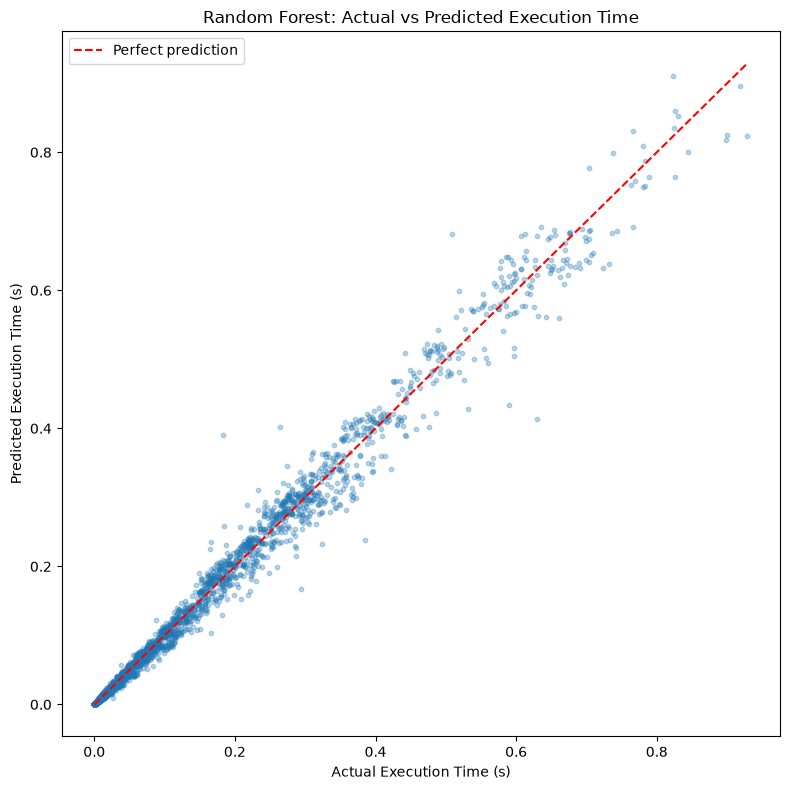

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, rf_preds, alpha=0.3, s=10)

lims = [min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")

ax.set_xlabel("Actual Execution Time (s)")
ax.set_ylabel("Predicted Execution Time (s)")
ax.set_title("Random Forest: Actual vs Predicted Execution Time")
ax.legend()
plt.tight_layout()
plt.savefig("../visualizations/actual_vs_predicted.png", dpi=150)
plt.show()

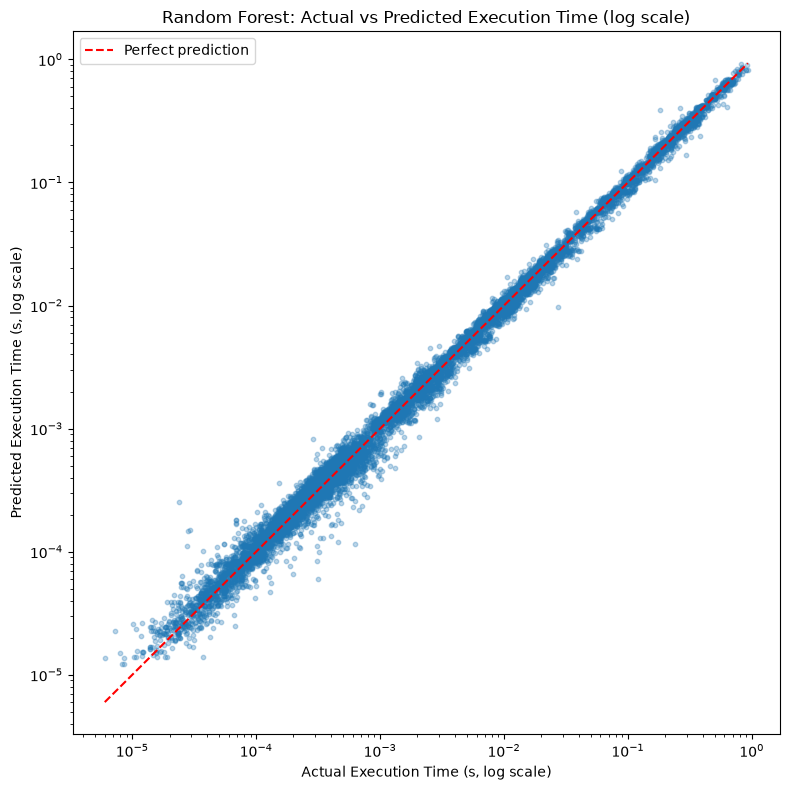

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, rf_preds, alpha=0.3, s=10)

lims = [max(y_test.min(), 1e-6), y_test.max()]
ax.plot(lims, lims, "r--", label="Perfect prediction")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual Execution Time (s, log scale)")
ax.set_ylabel("Predicted Execution Time (s, log scale)")
ax.set_title("Random Forest: Actual vs Predicted Execution Time (log scale)")
ax.legend()
plt.tight_layout()
plt.savefig("../visualizations/actual_vs_predicted_log.png", dpi=150)
plt.show()

## Regression Visualization

The Actual vs Predicted scatter plot shows tight clustering along the diagonal
across nearly the full range of execution times, with only mild scatter at the
high end (~0.4-0.9s), corresponding to bubble_sort's worst-case behavior on
large reverse-sorted arrays. No systematic over- or under-prediction bias is
visible in any region. A log-scale version confirms the model is also
well-calibrated on the sub-millisecond executions that make up the bulk of
the dataset, not just the visually dominant large outliers.

In [3]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(rf_pipeline, "../models/regression_model.pkl")
print("Regression model saved to models/regression_model.pkl")

Regression model saved to models/regression_model.pkl


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17648\3143145443.py:1: DtypeWarning: Columns (0: found) have mixed types. Specify dtype option on import or set low_memory=False.
  unified_df = pd.read_csv("../data/processed/unified_dataset.csv")


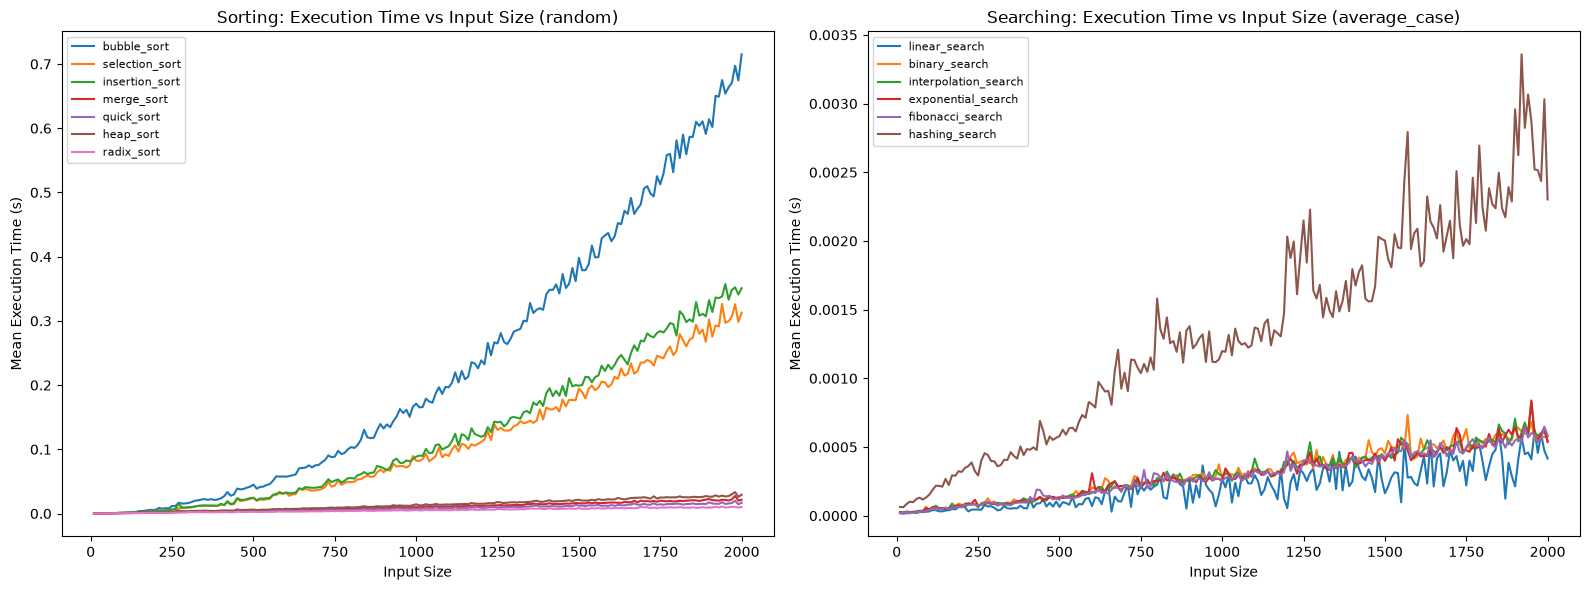

In [11]:
unified_df = pd.read_csv("../data/processed/unified_dataset.csv")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sorting: random data_type
sorting_data = unified_df[(unified_df["domain"] == "sorting") & (unified_df["input_condition"] == "random")]
for algo in sorting_data["algorithm"].unique():
    subset = sorting_data[sorting_data["algorithm"] == algo]
    means = subset.groupby("input_size")["time_taken"].mean()
    axes[0].plot(means.index, means.values, label=algo)
axes[0].set_title("Sorting: Execution Time vs Input Size (random)")
axes[0].set_xlabel("Input Size")
axes[0].set_ylabel("Mean Execution Time (s)")
axes[0].legend(fontsize=8)

# Searching: average_case
searching_data = unified_df[(unified_df["domain"] == "searching") & (unified_df["input_condition"] == "average_case")]
for algo in searching_data["algorithm"].unique():
    subset = searching_data[searching_data["algorithm"] == algo]
    means = subset.groupby("input_size")["time_taken"].mean()
    axes[1].plot(means.index, means.values, label=algo)
axes[1].set_title("Searching: Execution Time vs Input Size (average_case)")
axes[1].set_xlabel("Input Size")
axes[1].set_ylabel("Mean Execution Time (s)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../visualizations/execution_time_by_algorithm.png", dpi=150)
plt.show()

## Execution Time vs Input Size — Findings

- **Sorting:** O(n²) algorithms (bubble, selection, insertion) show clear
  quadratic growth; O(n log n)/O(n+k) algorithms (merge, quick, heap, radix)
  stay comparatively flat, consistent with theoretical complexity.
- **Searching:** Most algorithms show expected logarithmic/linear growth with
  mild noise. `hashing_search`, however, grows measurably with input size
  rather than staying flat/O(1) -- because the hash table is deliberately
  fixed-size (per Member A's engineering notes), so average chain length
  (and therefore lookup cost) increases as more items are packed into the
  same table. This distinguishes theoretical O(1) average-case hashing from
  practical performance under a fixed-capacity table, and is a useful
  discussion point for the final report.

In [4]:
import sys
print(f"Pipeline size check")
print(type(rf_pipeline))
print(rf_pipeline)

Pipeline size check
<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['input_size', 'comparisons',
                                                   'swaps_or_shifts',
                                                   'presortedness_score',
                                                   'duplicate_ratio',
                                                   'value_range', 'probes',
                                                   'collision_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['domain', 'algorithm',
                                                   'input_condition'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
    

In [5]:
rf_model = rf_pipeline.named_steps["model"]
print("n_estimators:", rf_model.n_estimators)
print("Number of trees actually fitted:", len(rf_model.estimators_))
depths = [tree.get_depth() for tree in rf_model.estimators_]
print("Max tree depth:", max(depths))
print("Mean tree depth:", np.mean(depths))

n_estimators: 200
Number of trees actually fitted: 200
Max tree depth: 52
Mean tree depth: 45.13
